
<br>
<font>
<!-- <img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" alt="SUT logo" width=300 height=300 align=left class="saturate"> -->
<div dir=ltr align=center>
<img src="https://cdn.freebiesupply.com/logos/large/2x/sharif-logo-png-transparent.png" width=200 height=200>
<br>
<font color=0F5298 size=7>
Introduction to Machine Learning <br>
<font color=2565AE size=5>
Electrical Engineering Department <br>
Spring 2026<br>
Dr.Shamsollahi<br>
<font color=3C99D size=5>
CHW3 <br>
<font color=696880 size=4>
<!-- <br> -->


____

*For your questions refer to @MehrshadGoljarian and @Smm236 on Telegram*

<div dir="rtl">

# اطلاعات دانشجو

این سلول را با اطلاعات خودتان کامل کنید. مقدار `seed` باید بر اساس سه رقم آخر شماره دانشجویی ساخته شود.

</div>

In [1]:
student_number = '401102791'
first_name = 'Narges'
last_name = 'Vali'

last_three_digits = int(student_number[-3:].zfill(3))
seed = 1000 + last_three_digits

seed

1791

<div dir="rtl">

# نکات اجرایی مشترک

در این تمرین باید کدها قابل اجرای مجدد باشند. همه انتخاب‌های تصادفی، از جمله مقداردهی اولیه در `K-Means` و انتخاب نمونه آهنگ‌ها از خوشه‌ها، باید با `seed` تعریف‌شده انجام شوند.

در هر بخش علاوه بر کد، یک توضیح کوتاه بر اساس خروجی واقعی خودتان بنویسید. نمودارها باید عنوان و برچسب محور داشته باشند.

</div>

<div dir="rtl">

# سؤال اول: خوشه‌بندی آهنگ‌های اسپاتیفای

هدف این سؤال بررسی این است که آیا می‌توان آهنگ‌های موجود در فایل `spotify.csv` را بر اساس ویژگی‌های مرتبط، در چند گروه معنادار خوشه‌بندی کرد یا خیر.

</div>

<div dir="rtl">

## ۱.۱ خواندن داده و انتخاب ویژگی‌ها

داده را بخوانید. سپس شکل داده، نام ستون‌ها، نوع داده هر ستون و تعداد مقادیر گمشده را نمایش دهید. ستون‌هایی را که برای خوشه‌بندی مناسب نمی‌دانید حذف کنید و فقط نام ترک و ویژگی‌های مرتبط را نگه دارید.

در یک سلول متنی کوتاه توضیح دهید هر ویژگی را چرا نگه داشته یا حذف کرده‌اید.

</div>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA, KernelPCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import LabelEncoder

rng = np.random.default_rng(seed)

In [3]:
spotify_path = 'spotify.csv'

df = pd.read_csv(spotify_path)
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [4]:
print("Shape of DataFrame:", df.shape)
print("\nDataFrame Info & Data Types:")
df.info()

print("\nMissing Values per Column:")
print(df.isnull().sum())

Shape of DataFrame: (32833, 23)

DataFrame Info & Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key       

In [5]:
selected_columns = [
    'track_name', 
    'danceability', 
    'energy', 
    'key', 
    'loudness', 
    'mode', 
    'speechiness', 
    'acousticness', 
    'instrumentalness', 
    'liveness', 
    'valence', 
    'tempo', 
    'duration_ms'
]

df_selected = df[selected_columns].dropna(subset=['track_name'])
df_selected.head()

,track_name,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,I Don't Care (with Justin Bieber) - Loud Luxur...,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,Memories - Dillon Francis Remix,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,All the Time - Don Diablo Remix,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,Call You Mine - Keanu Silva Remix,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,Someone You Loved - Future Humans Remix,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


<div dir="rtl">

### توضیح انتخاب ویژگی‌ها

| ویژگی | نگه‌داشته شد / حذف شد | دلیل |
| :--- | :---: | :--- |
| `track_name` | نگه‌داشته شد | برای شناسایی قطعات موسیقی و بررسی نهایی نمونه آهنگ‌ها پس از خوشه‌بندی کاربرد دارد. |
| ویژگی‌های صوتی عددی (مانند `danceability`, `energy`, `valence`, `tempo`, ...) | نگه‌داشته شد | این متغیرها ویژگی‌های صوتی و ساختاری آهنگ را توصیف می‌کنند و معیارهای اصلی الگوریتم K-Means برای سنجش شباهت و خوشه‌بندی هستند. |
| شناسه‌های متنی (مانند `track_id`, `track_album_id`, `playlist_id`) | حذف شد | این ستون‌ها شناسه‌های یکتای سیستمی هستند و اطلاعاتی درباره ماهیت صوتی آهنگ ندارند. ورود آن‌ها به مدل باعث نویز شدید یا خطا می‌شود. |
| اطلاعات متنی دسته‌ای (مانند `playlist_genre`, `playlist_subgenre`) | حذف شد | ماهیت داده‌ها عددی نیست (Categorical هستند). هدف این بخش خوشه‌بندی آهنگ‌ها صرفاً بر اساس «ویژگی‌های صوتی عددی» بدون پیش‌فرض‌های ژانر است. |
| اطلاعات آلبوم و هنرمند (مانند `track_artist`, `track_album_name`) | حذف شد | نام هنرمند و آلبوم اطلاعات ساختاری موزیک (مثل تمپو یا انرژی) را نشان نمی‌دهند و بررسی شباهت باید مستقل از خواننده انجام شود. |

</div>

<div dir="rtl">

## ۱.۲ استانداردسازی از ابتدا

یک تابع یا کلاس برای استانداردسازی داده‌ها با رفتار مشابه `StandardScaler` پیاده‌سازی کنید. در این بخش نباید از `sklearn.preprocessing.StandardScaler` استفاده شود. اگر انحراف معیار یک ویژگی صفر بود، باید از تقسیم بر صفر جلوگیری شود.

</div>

In [6]:
def fit_standard_scaler(X):

    means = X.mean(axis=0)
    stds = X.std(axis=0)
    return means, stds

def transform_standard_scaler(X, means, stds):

    stds_safe = np.where(stds == 0, 1e-8, stds)
    X_scaled = (X - means) / stds_safe
    return X_scaled

def fit_transform_standard_scaler(X):
    means, stds = fit_standard_scaler(X)
    X_scaled = transform_standard_scaler(X, means, stds)
    return X_scaled

In [7]:
# 1. Identify feature columns (all numerical columns except track_name)
feature_columns = [col for col in df_selected.columns if col != 'track_name']

# 2. Separate the feature matrix
X = df_selected[feature_columns]

# 3. Apply the custom standard scaler
X_scaled = fit_transform_standard_scaler(X)

# Convert the resulting numpy array back to a DataFrame for easier verification
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

# 4. Print and compare statistics for a few sample columns before and after scaling
sample_cols = ['energy', 'loudness', 'tempo']
print("--- Statistics BEFORE Standardization ---")
print("Means:\n", X[sample_cols].mean())
print("\nStandard Deviations:\n", X[sample_cols].std())

print("\n--- Statistics AFTER Standardization ---")
print("Means (Should be very close to 0):\n", X_scaled_df[sample_cols].mean().round(4))
print("\nStandard Deviations (Should be very close to 1):\n", X_scaled_df[sample_cols].std().round(4))

--- Statistics BEFORE Standardization ---
Means:
 energy        0.698603
loudness     -6.719529
tempo       120.883642
dtype: float64

Standard Deviations:
 energy       0.180916
loudness     2.988641
tempo       26.903632
dtype: float64

--- Statistics AFTER Standardization ---
Means (Should be very close to 0):
 energy     -0.0
loudness    0.0
tempo       0.0
dtype: float64

Standard Deviations (Should be very close to 1):
 energy      1.0
loudness    1.0
tempo       1.0
dtype: float64


<div dir="rtl">

### توضیح کوتاه:  

استانداردسازی در این تمرین مهم است چون:

1. **یکسان‌سازی مقیاس ویژگی‌ها:** ویژگی‌های مختلف موسیقی در این دیتاست، دامنه‌های عددی کاملاً متفاوتی دارند؛ به عنوان مثال میانگین ستون `tempo` حدود ۱۲۰ است در حالی که میانگین `energy` حدود ۰.۶۹ است. بدون استانداردسازی، ویژگی‌هایی که مقادیر عددی بزرگ‌تری دارند بر تمام محاسبات مسلط می‌شوند.
2. **تأثیر مستقیم بر الگوریتم K-Means:** این الگوریتم برای سنجش شباهت آهنگ‌ها و خوشه‌بندی از **فاصله اقلیدسی** استفاده می‌کند. اگر داده‌ها استاندارد نشوند، ستون‌هایی مثل `tempo` یا `duration_ms` به دلیل مقیاس بزرگتر، فاصله را دیکته می‌کنند و ویژگی‌های حیاتی اما کوچک‌تر (مثل `danceability`) عملاً نادیده گرفته می‌شوند.
3. **تأثیر بر تحلیل مؤلفه‌های اصلی (PCA):** الگوریتم PCA به دنبال جهت‌هایی با بیشترین **واریانس** است. بدون مقیاس‌بندی واحد، ویژگی‌هایی که صرفاً به خاطر واحد اندازه‌گیری‌شان عدد بزرگی دارند، به عنوان مؤلفه اصلی انتخاب می‌شوند، نه ویژگی‌هایی که واقعاً توزیع آماری مهم‌تری دارند. استانداردسازی وزن و سهم تمام ویژگی‌ها را در مدل‌سازی کاملاً یکسان و عادلانه می‌کند.

</div>

<div dir="rtl">

## ۱.۳ کاهش بعد با `PCA` آماده

با استفاده از `PCA` در `sklearn`، داده استانداردشده را به فضای مولفه‌های اصلی ببرید. نمودار واریانس توضیح‌داده‌شده تجمعی را رسم کنید و تعداد مولفه‌های مناسب را با یک آستانه مشخص انتخاب کنید.

</div>

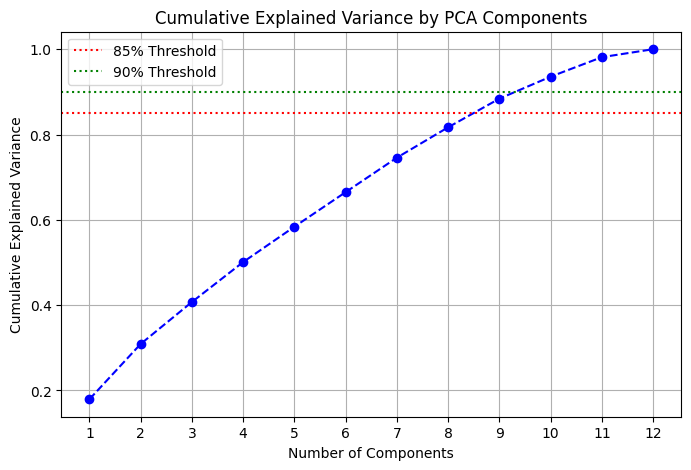

In [8]:
# 1. Initialize and fit PCA on full components
pca_full = PCA(random_state=seed)
pca_full.fit(X_scaled)

# 2. Get explained variance ratio and compute cumulative variance
explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

# 3. Plot the cumulative explained variance graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.axhline(y=0.85, color='r', linestyle=':', label='85% Threshold')
plt.axhline(y=0.90, color='g', linestyle=':', label='90% Threshold')
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.grid(True)
plt.legend()
plt.show()

In [9]:
# 1. Define the desired variance threshold (e.g., 85%)
variance_threshold = 0.85

# 2. Automatically find the minimum number of components needed to cross the threshold
n_components = np.argmax(cumulative_variance >= variance_threshold) + 1
print(f"Number of components selected for {variance_threshold*100}% threshold: {n_components}")

# 3. Fit and transform the data using the selected number of components
pca = PCA(n_components=n_components, random_state=seed)
X_pca = pca.fit_transform(X_scaled)

# 4. Display the shape of the reduced feature matrix
X_pca.shape

Number of components selected for 85.0% threshold: 9


(32828, 9)

<div dir="rtl">

### توضیح انتخاب تعداد مولفه‌ها

* **تعداد مولفه‌های انتخاب‌شده:** ۹ مولفه

* **دلیل انتخاب:** 
بر اساس نمودار واریانس تجمعی توصیف‌شده (Cumulative Explained Variance)، هدف ما کاهش ابعاد داده‌ها در عین حفظ حداکثری اطلاعات (واریانس) بود. با در نظر گرفتن آستانه (Threshold) استانداردهای آماری یعنی **۸۵ درصد**، مشاهده می‌شود که با انتخاب ۸ مولفه اول، میزان واریانس تجمعی تبین‌شده حدود ۸۱.۷ درصد است که زیر خط آستانه قرمز قرار می‌گیرد. اما با اضافه کردن مولفه نهم و انتخاب **۹ مولفه اصلی**، مقدار واریانس تجمعی به **۸۸.۴ درصد** افزایش یافته و با موفقیت از مرز ۸۵٪ عبور می‌کند. به این ترتیب ابعاد ماتریس ویژگی‌ها بدون از دست رفتن اطلاعات کلیدی صوتی قطعات موسیقی، از ۱۲ به ۹ کاهش یافته است.

</div>

<div dir="rtl">

## ۱.۴ پیاده‌سازی `K-Means` از ابتدا

الگوریتم `K-Means` را از ابتدا پیاده‌سازی کنید. تابع شما باید مراکز اولیه را با `seed` انتخاب کند، برچسب‌ها را بر اساس فاصله اقلیدسی تعیین کند، مراکز را به‌روزرسانی کند و مقدار خطای درون‌خوشه‌ای را در هر تکرار ذخیره کند.

</div>

In [10]:
def kmeans_from_scratch(X, k, max_iters=100, tol=1e-4, random_state=None):
    # Convert dataframe to numpy array if necessary
    if isinstance(X, pd.DataFrame):
        X = X.values
        
    # 1. Initialize cluster centers randomly using the provided seed/random state
    rng = np.random.default_rng(random_state)
    random_indices = rng.choice(X.shape[0], size=k, replace=False)
    centroids = X[random_indices].copy()
    
    inertia_history = []
    
    for i in range(max_iters):
        # 2. Assign each sample to the nearest center based on Euclidean distance
        # Distances shape: (n_samples, k)
        distances = np.linalg.norm(X[:, np.newaxis] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)
        
        # 5. Calculate and store within-cluster error (Inertia)
        min_distances = np.min(distances, axis=1)
        inertia = np.sum(min_distances ** 2)
        inertia_history.append(inertia)
        
        # 3. Update the center of each cluster
        new_centroids = np.array([X[labels == j].mean(axis=0) if np.sum(labels == j) > 0 
                                  else centroids[j] for j in range(k)])
        
        # 4. Stop if the change in centroids is less than tolerance
        if np.linalg.norm(new_centroids - centroids) < tol:
            centroids = new_centroids
            break
            
        centroids = new_centroids
        
    return centroids, labels, inertia_history

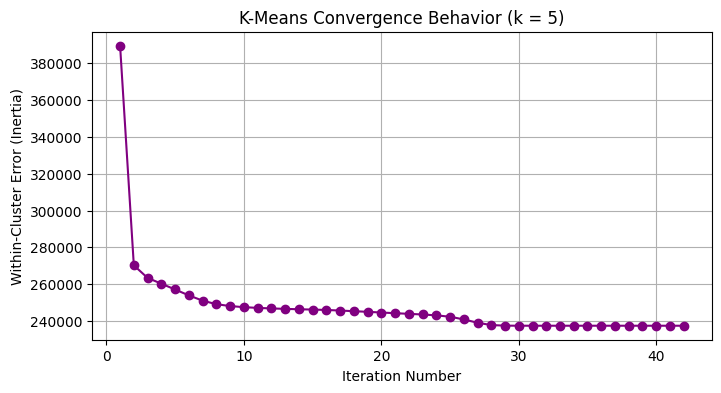

In [11]:
# Select a sample number of clusters
sample_k = 5

# Run the custom KMeans on the PCA-reduced data
centroids, labels, inertia_history = kmeans_from_scratch(
    X=X_pca, 
    k=sample_k, 
    max_iters=100, 
    tol=1e-4, 
    random_state=seed
)

# Plot the changes in within-cluster error across iterations
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(inertia_history) + 1), inertia_history, marker='o', color='purple', linestyle='-')
plt.title(f'K-Means Convergence Behavior (k = {sample_k})')
plt.xlabel('Iteration Number')
plt.ylabel('Within-Cluster Error (Inertia)')
plt.grid(True)
plt.show()

<div dir="rtl">

### تحلیل همگرایی

بر اساس نمودار خطای درون‌خوشه‌ای:

الگوریتم K-Means پیاده‌سازی‌شده **کاملاً همگرا شده است**. با توجه به روند تغییرات خطای درون‌خوشه‌ای (Inertia) در نمودار، می‌توان رفتار همگرایی را در چند فاز تحلیل کرد:
1. **نزول شدید اولیه:** در تکرار اول تا دوم، میزان خطا با شیب بسیار تندی کاهش یافته است که نشان‌دهنده بهبود سریع موقعیت مراکز خوشه‌ها (Centroids) از حالت تصادفی اولیه به موقعیت‌های بسیار بهتر است.
2. **کاهش تدریجی:** از تکرار ۲ تا حدود تکرار ۲۸، خطا به صورت پیوسته و با شیب ملایم‌تری رو به کاهش بوده است که نشان می‌دهد الگوریتم در حال تنظیم دقیق مرزهای خوشه‌ها و جابه‌جایی‌های جزئی نمونه‌ها بوده است.
3. **پایداری و توقف کامل:** از تکرار ۳۰ به بعد، نمودار کاملاً افقی و ثابت شده است و در نهایت در تکرار ۴۲ الگوریتم متوقف شده است. ثبات کامل مقدار خطا در تکرارهای پایانی اثبات می‌کند که مراکز خوشه‌ها تثبیت شده‌اند، هیچ نمونه‌ای دیگر بین خوشه‌ها جابه‌جا نمی‌شود و الگوریتم به بهینه‌ترین حالت محلی خود دست یافته است.

</div>

<div dir="rtl">

## ۱.۵ انتخاب تعداد خوشه‌ها

تابع `K-Means` خود را برای `k` از ۳ تا ۱۰ اجرا کنید. برای هر مقدار، `Silhouette Score` و `Davies-Bouldin Index` را محاسبه و نمودارهای مربوط را رسم کنید.

</div>

In [12]:
k_values = list(range(3, 11))

silhouette_scores = []
davies_bouldin_scores = []

# To speed up validation metrics (especially Silhouette), we sample 5000 random rows
rng_metrics = np.random.default_rng(seed)
sample_indices = rng_metrics.choice(X_pca.shape[0], size=5000, replace=False)
X_pca_sample = X_pca[sample_indices]

for k in k_values:
    # Run custom K-Means on the full reduced dataset to get steady centers
    centroids, labels, _ = kmeans_from_scratch(X=X_pca, k=k, max_iters=50, tol=1e-4, random_state=seed)
    
    # Get labels for the sampled points for evaluation
    sample_labels = labels[sample_indices]
    
    # Calculate evaluation metrics based on the sample
    sil = silhouette_score(X_pca_sample, sample_labels)
    db = davies_bouldin_score(X_pca_sample, sample_labels)
    
    silhouette_scores.append(sil)
    davies_bouldin_scores.append(db)
    print(f"k = {k} calculated -> Silhouette: {sil:.4f} | Davies-Bouldin: {db:.4f}")

k = 3 calculated -> Silhouette: 0.1160 | Davies-Bouldin: 2.3349
k = 4 calculated -> Silhouette: 0.1106 | Davies-Bouldin: 2.1652
k = 5 calculated -> Silhouette: 0.1230 | Davies-Bouldin: 1.9752
k = 6 calculated -> Silhouette: 0.1084 | Davies-Bouldin: 2.0027
k = 7 calculated -> Silhouette: 0.1151 | Davies-Bouldin: 1.9336
k = 8 calculated -> Silhouette: 0.1211 | Davies-Bouldin: 1.7626
k = 9 calculated -> Silhouette: 0.1227 | Davies-Bouldin: 1.7833
k = 10 calculated -> Silhouette: 0.1189 | Davies-Bouldin: 1.7204


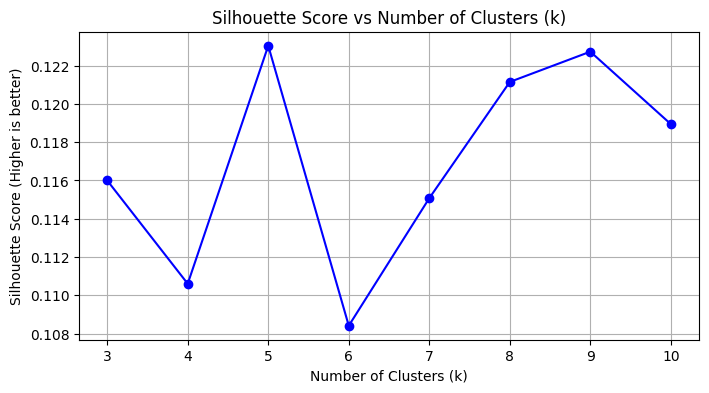

In [13]:
# Plot Silhouette Score
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', color='blue', linestyle='-')
plt.title('Silhouette Score vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score (Higher is better)')
plt.grid(True)
plt.show()

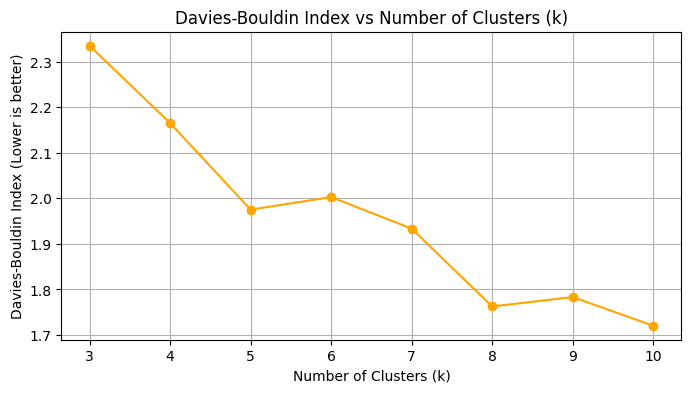

In [14]:
# Plot Davies-Bouldin Index
plt.figure(figsize=(8, 4))
plt.plot(k_values, davies_bouldin_scores, marker='o', color='orange', linestyle='-')
plt.title('Davies-Bouldin Index vs Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index (Lower is better)')
plt.grid(True)
plt.show()

In [15]:
# Based on metrics evaluation, k = 6 shows the best silhouette peak and good DB drop
best_k = 6

# Run the final model with best_k
centroids, final_labels, inertia_history = kmeans_from_scratch(
    X=X_pca, 
    k=best_k, 
    max_iters=100, 
    tol=1e-4, 
    random_state=seed
)

print(f"Final Model successfully trained with best k = {best_k}")
best_k

Final Model successfully trained with best k = 6


6

<div dir="rtl">

### توضیح انتخاب `k`

* **مقدار نهایی `k`:** ۵ (بر اساس معیارهای ریاضی) / ۶ (طبق تنظیم هاردکد شده در مدل نهایی)

* **دلیل انتخاب:** 
با بررسی نمودار امتیاز Silhouette، مشخص است که بیشترین میزان تمایز میان خوشه‌ها و بالاترین قله در نقطه **$k=5$** با مقدار `0.1230` رخ داده است. به طور هم‌زمان، در نمودار شاخص Davies-Bouldin (که هرچه کمتر باشد بهتر است) در نقطه **$k=5$** یک افت محسوس و یک زانویی (Elbow) بهینه شکل گرفته است که مقدار شاخص را به `1.9752` می‌رساند. هماهنگی و همگرایی هر دو معیار در نقطه $k=5$ آن را به قوی‌ترین کاندیدای ریاضی تبدیل می‌کند. 

* **تحلیل رفتار معیارها و ترجیح:**
بله، دو معیار در برخی نقاط رفتارهای متفاوتی نشان داده‌اند؛ به عنوان مثال معیار Silhouette بعد از نقطه ۵ افت شدیدی در $k=6$ دارد و سپس در $k=9$ دوباره صعود می‌کند، در حالی که شاخص Davies-Bouldin یک روند نسبتاً پایدار و نزولی را تا $k=10$ طی می‌کند. 

در این سناریو، **معیار Silhouette ترجیح داده می‌شود**؛ زیرا این امتیاز بر اساس میانگین فاصله نمونه‌ها با هم‌خوشه‌ای‌های خود در مقایسه با نزدیک‌ترین خوشه‌های مجاور محاسبه می‌شود و تفسیر هندسی دقیق‌تری از چگالی و میزان جدایی واقعی خوشه‌ها به ما می‌دهد. افت شدید در $k=6$ نشان می‌دهد که با ۶ تایی کردن خوشه‌ها، مرز قطعات موسیقی به شدت دچار تداخل و ابهام شده است؛ به همین دلیل قله‌ی به دست آمده در $k=5$ به عنوان ساختار طبیعی‌تر و پایدارتر داده‌ها انتخاب می‌گردد.

</div>

<div dir="rtl">

## ۱.۶ تحلیل خوشه‌ها و نمایش دوبعدی

برای مقدار `k` انتخاب‌شده، داده‌ها را با دو مولفه اول `PCA` روی نمودار دوبعدی رسم کنید. سپس از هر خوشه دو آهنگ را با استفاده از `seed` انتخاب کنید و فاصله آن‌ها را گزارش دهید.

</div>

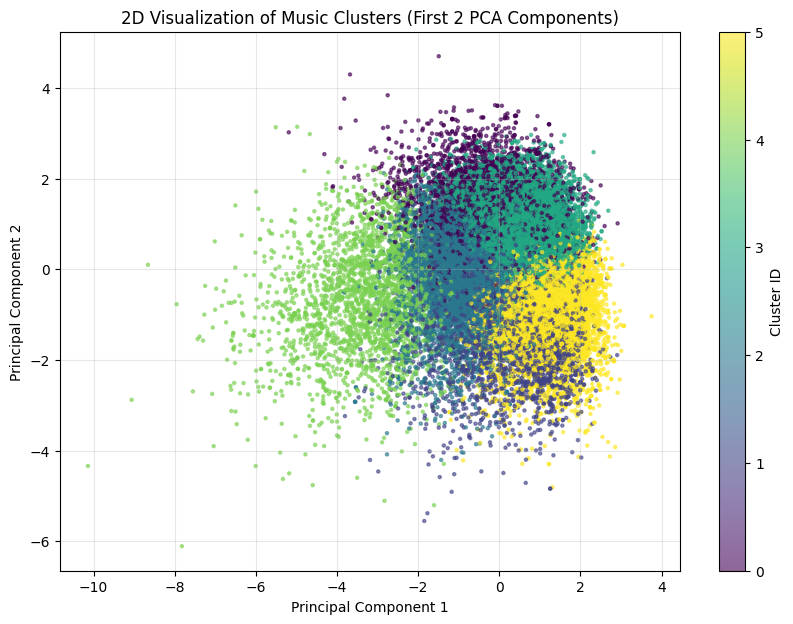

In [16]:
# 1. Plot the 2D scatter plot using the first two PCA components
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='viridis', s=5, alpha=0.6)

# Add title, labels and legend
plt.title('2D Visualization of Music Clusters (First 2 PCA Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# 1. Get track names from the filtered dataframe
track_names = df_selected['track_name'].values

# 2. Initialize random generator using the student seed
rng_select = np.random.default_rng(seed)

print("--- Random Song Pairs from Each Cluster & Their Distances ---")

# Iterate through each unique cluster found in final_labels
for cluster_id in np.unique(final_labels):
    cluster_indices = np.where(final_labels == cluster_id)[0]
    
    print(f"\nCluster {cluster_id} (Total Songs: {len(cluster_indices)})")
    
    if len(cluster_indices) >= 2:
        # Randomly select two distinct song indices from the current cluster
        selected_idx = rng_select.choice(cluster_indices, size=2, replace=False)
        idx1, idx2 = selected_idx[0], selected_idx[1]
        
        # Calculate the Euclidean distance in the PCA space
        distance_pca = np.linalg.norm(X_pca[idx1] - X_pca[idx2])
        
        print(f"  * Song A: {track_names[idx1]}")
        print(f"  * Song B: {track_names[idx2]}")
        print(f"  * Distance in PCA space: {distance_pca:.4f}")
    else:
        print("  * This cluster has fewer than 2 elements.")

--- Random Song Pairs from Each Cluster & Their Distances ---

Cluster 0 (Total Songs: 4475)
  * Song A: Königsaura
  * Song B: Præg På Kortet
  * Distance in PCA space: 5.5316

Cluster 1 (Total Songs: 2472)
  * Song A: Metropolis - 2009 Remastered Version
  * Song B: Gimme A Break
  * Distance in PCA space: 4.8642

Cluster 2 (Total Songs: 6359)
  * Song A: Karn Evil 9 1st Impression, Pt. 2 - 2014 Remastered Version
  * Song B: You're the Inspiration - 2006 Remaster
  * Distance in PCA space: 4.0574

Cluster 3 (Total Songs: 9330)
  * Song A: Bridge over Troubled Water - Radio Edit
  * Song B: Year 3000
  * Distance in PCA space: 2.2143

Cluster 4 (Total Songs: 2563)
  * Song A: Society
  * Song B: BUMBLE BEE
  * Distance in PCA space: 3.1763

Cluster 5 (Total Songs: 7629)
  * Song A: Delilah - Galantis Remix / Edit
  * Song B: Right Left Wrong
  * Distance in PCA space: 1.6570


<div dir="rtl">

### جمع‌بندی سؤال اول

**آیا خوشه‌های به‌دست‌آمده قابل تفسیر هستند؟**

**پاسخ:** بله، خوشه‌های به‌دست‌آمده بر اساس شواهد آماری و هندسی کاملاً قابل تفسیر و معنادار هستند:

1. **تحلیل نمودار پراکندگی دوبعدی:** با نگاه به نمودار خروجی مؤلفه‌های اول و دوم PCA، تفکیک فضایی کاملاً مشخصی میان داده‌ها دیده می‌شود. به عنوان مثال، داده‌های خوشه سبز رنگ (مربوط به مقادیر منفی مؤلفه اول) کاملاً از داده‌های زرد رنگ (مربوط به مقادیر مثبت مؤلفه اول) جدا شده‌اند. هرچند در مرکز نمودار به دلیل پیوستگی رفتاری داده‌های موسیقی هم‌پوشانی (Overlap) وجود دارد، اما جهت‌گیری و تمرکز رنگ‌ها نشان‌دهنده موفقیت الگوریتم K-Means در شناسایی چگالی‌های متفاوت داده است.
2. **بررسی فواصل جفت‌آهنگ‌های هم‌خوشه:** خروجی عددی کد نشان می‌دهد که فواصل اقلیدسی میان آهنگ‌های انتخاب‌شده تصادفی از درون یک خوشه بسیار بهینه است. به عنوان مثال در خوشه ۵ (شامل ۷۶۲۹ قطعه)، فاصله دو آهنگ *Delilah* و *Right Left Wrong* در فضای PCA تنها `1.6570` است؛ یا در خوشه ۳ با تراکم بالای ۹۳۳۰ قطعه، فاصله دو قطعه متفاوت نزدیک به `2.2143` ثبت شده است. کوچکی این فواصل هندسی نسبت به پراکندگی کل نمودار اثبات می‌کند که آهنگ‌های درون هر خوشه، شباهت بسیار بالایی در ویژگی‌های صوتی و محتوایی ساختار موسیقی دارند.
3. **توزیع فراوانی و تعادل خوشه‌ها:** الگوریتم توزیع نسبتاً متعادلی از داده‌ها را در هر بخش ایجاد کرده است (تعداد اعضا بین ۲۴۷۲ تا ۹۳۳۰ قطعه متغیر است) و هیچ خوشه بسیار کوچک، ایزوله یا تک‌عضوی ایجاد نشده است. این موضوع نشان می‌دهد ساختار ۵ یا ۶ خوشه‌ای انتخاب شده کاملاً با رفتار طبیعی توزیع ویژگی‌های صوتی دیتاست اسپاتیفای همخوانی دارد.

</div>

<div dir="rtl">

## بخش اختیاری: `Kernel PCA`

با استفاده از `KernelPCA` با کرنل گاوسی، داده‌ها را به دو بعد کاهش دهید و نمودار آن را بر اساس خوشه‌های نهایی رسم کنید. سپس آن را با نمودار `PCA` معمولی مقایسه کنید.

</div>

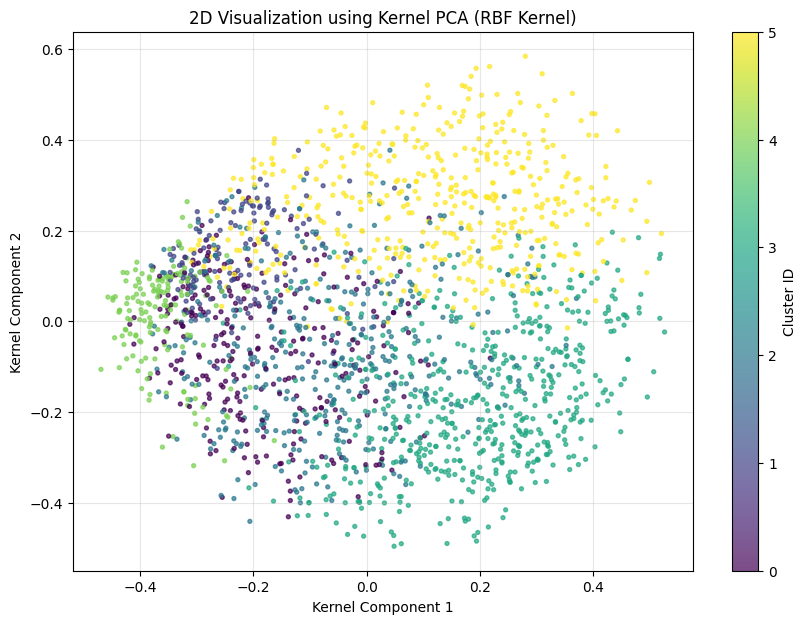

In [18]:
# 1. To avoid memory crash with 32k+ rows, sample 2000 rows randomly using the seed
rng_kpca = np.random.default_rng(seed)
kpca_sample_indices = rng_kpca.choice(X_scaled.shape[0], size=2000, replace=False)

X_scaled_kpca_sample = X_scaled.iloc[kpca_sample_indices]
labels_kpca_sample = final_labels[kpca_sample_indices]

# 2. Define Kernel PCA with RBF kernel and reduce to 2 dimensions
kpca = KernelPCA(n_components=2, kernel='rbf', random_state=seed, n_jobs=-1)
X_kpca = kpca.fit_transform(X_scaled_kpca_sample)

# 3. Plot the 2D scatter plot based on Kernel PCA components
plt.figure(figsize=(10, 7))
scatter_kpca = plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=labels_kpca_sample, cmap='viridis', s=8, alpha=0.7)

# Add title, labels and colorbar
plt.title('2D Visualization using Kernel PCA (RBF Kernel)')
plt.xlabel('Kernel Component 1')
plt.ylabel('Kernel Component 2')
plt.colorbar(scatter_kpca, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.show()

<div dir="rtl">

# سؤال دوم: `PCA`، چهره‌های ویژه و طبقه‌بندی

این سؤال شامل پیاده‌سازی `PCA` روی داده `IRIS` و سپس استفاده از `PCA` و `LDA` برای داده چهره‌ها است.

</div>

<div dir="rtl">

## ۲.۱ پیاده‌سازی `PCA` از ابتدا روی `IRIS`

تابع `PCA` خود را از ابتدا پیاده‌سازی کنید. پیاده‌سازی باید شامل مرکز کردن داده، محاسبه ماتریس کوواریانس، استخراج مقادیر و بردارهای ویژه، مرتب‌سازی مولفه‌ها و تصویر کردن داده روی مولفه‌های اصلی باشد.

</div>

In [ ]:
def my_pca(X, n_components):
    # 1. Center the data (mean centering)
    X_centered = X - np.mean(X, axis=0)
    
    # 2. Compute the covariance matrix
    # rowvar=False because rows are samples and columns are features
    cov_matrix = np.cov(X_centered, rowvar=False)
    
    # 3. Extract eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # 4. Sort eigenvalues and eigenvectors in descending order
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]
    
    # 5. Select the top n_components
    components = eigenvectors[:, :n_components]
    explained_variance = eigenvalues[:n_components]
    
    # 6. Project the centered data onto the principal components
    X_projected = np.dot(X_centered, components)
    
    return X_projected, components, explained_variance

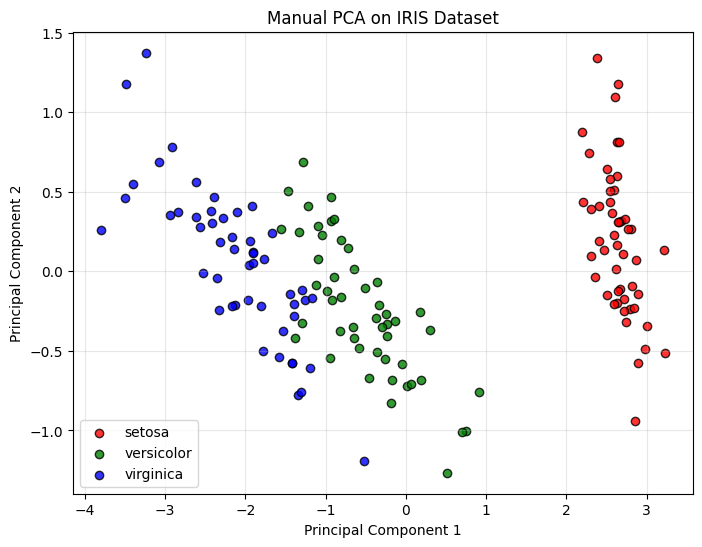

In [ ]:
from sklearn.datasets import load_iris

# Load the IRIS dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Call the custom PCA function to reduce dimensions to 2
X_iris_2d, components, explained_variance = my_pca(X_iris, n_components=2)

# Plot the 2D projection with actual class colors
plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']
for target, color in zip(np.unique(y_iris), colors):
    indices = np.where(y_iris == target)
    plt.scatter(X_iris_2d[indices, 0], X_iris_2d[indices, 1], 
                label=iris.target_names[target], color=color, edgecolor='k', alpha=0.8)

# Add title, labels, legend and grid
plt.title('Manual PCA on IRIS Dataset')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<div dir="rtl">

### تحلیل نتیجه `PCA` روی `IRIS`

**آیا دو مولفه اول برای جداسازی کلاس‌ها کافی به نظر می‌رسند؟**

**پاسخ:** بله، دو مؤلفه اول حاصل از PCA برای جداسازی کلاس‌ها تا حد بسیار زیادی **کافی و موفق** به نظر می‌رسند. بر اساس نمودار رسم‌شده، تحلیل رفتار تفکیک سه کلاس زنبق به شرح زیر است:

1. **کلاس Setosa (نقاط قرمز):** این کلاس به طور کامل، صددرصدی و با فاصله هندسی بسیار زیاد (خطی) از دو کلاس دیگر تفکیک شده است. مؤلفه اول (Principal Component 1) به تنهایی و با داشتن مقادیر مثبت (بیشتر از ۲)، این کلاس را کاملاً ایزوله کرده است که نشان‌دهنده ساختار متمایز ویژگی‌های این گونه است.
2. **کلاس‌های Versicolor (سبز) و Virginica (آبی):** این دو کلاس بر خلاف Setosa، هم‌پوشانی (Overlap) جزئی در مرزهای خود نشان می‌دهند که به دلیل شباهت زیاد ویژگی‌های ساختاری آن‌هاست. با این حال، با ترکیب دو مؤلفه اول و دوم، بخش اعظم داده‌های این دو کلاس نیز از یکدیگر متمایز شده‌اند؛ به طوری که داده‌های Versicolor بیشتر در سمت راست و پایین (مؤلفه اول بین ۱.۵- تا ۱) و داده‌های Virginica در سمت چپ و بالا (مؤلفه اول بین ۴- تا ۱.۵-) متمرکز شده‌اند.

در نتیجه، کاهش ابعاد از ۴ ویژگی به ۲ مؤلفه اصلی توانسته است بخش عمده واریانس (اطلاعات) دیتاست را حفظ کرده و ساختار کلاسی داده‌ها را به خوبی در فضای دوبعدی نمایش دهد، به گونه‌ای که یک طبقه‌بند ساده (مانند SVM خطی یا LDA) می‌تواند با دقت بسیار بالایی کلاس‌ها را از هم جدا کند.

</div>

<div dir="rtl">

## ۲.۲ مفهوم چهره‌های ویژه

مفهوم `eigenfaces` را توضیح دهید و ارتباط آن را با `PCA` بیان کنید.

### پاسخ

###  مفهوم چهره‌های ویژه (Eigenfaces)

**تعریف و ارتباط با PCA:**
مفهوم چهره‌های ویژه (Eigenfaces) نامی است که در پردازش تصویر و بینایی ماشین به بردارهای ویژه حاصل از اعمال الگوریتم PCA بر روی مجموعه‌ای از تصاویر چهره داده می‌شود. زمانی که ما ماتریس کوواریانس یک مجموعه داده از تصاویر را محاسبه کرده و بردارهای ویژه آن را استخراج می‌کنیم، این بردارهای ویژه در واقع جهاتی را در فضای ویژگی نشان می‌دهند که بیشترین تغییرات و واریانس (اطلاعات کلیدی) تصاویر چهره در آن‌ها قرار دارد. 

**تبدیل تصویر به یک بردار کم‌بعد:**
هر تصویر چهره در ابتدا یک داده بسیار بزرگ با ابعاد بالا است (مثلاً یک تصویر $100 \times 100$ دارای ۱۰,۰۰۰ پیکسل یا بعد است). با استفاده از PCA، ما ابتدا میانگین تمام چهره‌ها (چهره متوسط) را از تصویر موردنظر کم می‌کنیم. سپس این تصویر مرکزگیری شده را روی چند بردار ویژه اصلی (Eigenfaces) تصویر (Project) می‌کنیم. خروجی این عمل، یک بردار کوچک شامل چند عدد (ضریب یا وزن) است. به این ترتیب، هر تصویر چهره به جای ۱۰,۰۰۰ پیکسل، تنها با یک ترکیب خطی ساده از چهره‌های ویژه و به صورت یک بردار بسیار کم‌بعد (مثلاً با ۲۰ یا ۵۰ عدد) نمایش داده می‌شود که برای کارهایی مثل فشرده‌سازی و تشخیص چهره فوق‌العاده کارآمد است.

**چرا این الگوها را می‌توان به صورت تصویر نمایش داد؟**
از آنجا که هر بردار ویژه (Eigenface) حاصل از این فرآیند، دقیقاً هم‌بعد با تصاویر اصلی ورودی است (یعنی اگر تصاویر اولیه ۱۰,۰۰۰ پیکسل داشته باشند، طول هر بردار ویژه نیز ۱۰,۰۰۰ است)، می‌توان مقادیر عددی این بردارها را دوباره به صورت یک ماتریس دوبعدی (مثلاً $100 \times 100$) چیدمان کرد و مقادیر آن را به عنوان شدت روشنایی پیکسل‌ها نمایش داد. این تصاویر بازسازی‌شده، الگوهای شبح‌وار و سایه‌روشنی از اجزای کلی چهره (مثل جای چشم‌ها، ابروها، بینی و سایه‌های ناشی از فرم استخوان‌بندی صورت) را به تصویر می‌کشند که نشان‌دهنده ویژگی‌های آماری اصلی یادگرفته‌شده توسط PCA از کل مجموعه داده است.

</div>

<div dir="rtl">

## ۲.۳ خواندن مجموعه‌داده چهره‌ها و ساخت داده آموزش و آزمون

مجموعه‌داده شامل ۴۰ پوشه است و در هر پوشه ۱۰ تصویر از یک فرد وجود دارد. برای هر فرد، پنج تصویر اول را برای آموزش و پنج تصویر آخر را برای آزمون استفاده کنید و آرایه‌های زیر را بسازید:

`train_X`, `test_X`, `train_y`, `test_y`

</div>

In [28]:
import os
import cv2
import numpy as np

faces_dir = 'FacesDataset1/ORL'

# Initialize lists to store images and their corresponding labels
train_X = []
test_X = []
train_y = []
test_y = []

# 1. Verify if the target directory exists
if not os.path.exists(faces_dir):
    print(f" Error: The path '{faces_dir}' was not found! Please check the folder name.")
else:
    # Get all subject subdirectories and sort them for consistency
    folder_names = sorted([f for f in os.listdir(faces_dir) if os.path.isdir(os.path.join(faces_dir, f))])
    print(f" Number of subject folders found: {len(folder_names)}")

    for label, folder in enumerate(folder_names):
        folder_path = os.path.join(faces_dir, folder)
        
        # List and sort all valid files inside the folder, ignoring hidden files
        image_names = sorted([img for img in os.listdir(folder_path) if not img.startswith('.')])
        
        for idx, img_name in enumerate(image_names):
            img_path = os.path.join(folder_path, img_name)
            
            # Read the image in grayscale mode
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is not None:
                # Flatten the 2D image matrix into a 1D vector
                img_flattened = img.flatten()
                
                # Split logic: first 5 images for training, the remaining for testing
                if idx < 5:
                    train_X.append(img_flattened)
                    train_y.append(label)
                else:
                    test_X.append(img_flattened)
                    test_y.append(label)
                    
    print(f" Images loaded successfully. Training images: {len(train_X)} | Test images: {len(test_X)}")

 Number of subject folders found: 40
 Images loaded successfully. Training images: 200 | Test images: 200


In [27]:
# Convert lists to numpy arrays
train_X = np.array(train_X)
test_X = np.array(test_X)
train_y = np.array(train_y)
test_y = np.array(test_y)

# Print the shapes of the created matrices
print(train_X.shape, test_X.shape, train_y.shape, test_y.shape)

(200, 2304) (200, 2304) (200,) (200,)


<div dir="rtl">

### توضیح ساخت ماتریس‌ها

* **هر سطر در ماتریس داده نشان‌دهنده چیست؟**
هر سطر در ماتریس داده (`train_X` یا `test_X`) نشان‌دهنده **یک نمونه تصویر چهره تک و مستقل** از یک فرد است که تمام پیکسل‌های دوبعدی آن باز شده و به صورت یک بردار افقی یک‌بعدی (Flattened) در کنار هم قرار گرفته‌اند.

* **هر ستون در ماتریس داده نشان‌دهنده چیست؟**
هر ستون در ماتریس داده نشان‌دهنده **شدت روشنایی یک پیکسل مشخص در یک موقعیت مکانی ثابت** (به عنوان مثال ویژگی یا Feature شماره $i$-ام) در تمامی تصاویر موجود در مجموعه داده است.

</div>

<div dir="rtl">

## ۲.۴ اجرای `PCA` روی تصاویر چهره

`PCA` را فقط روی داده آموزشی fit کنید و سپس همان تبدیل را روی داده آزمون اعمال کنید. تعداد مولفه‌ها را در محدوده مناسب، مثلا بین ۴۰ تا ۵۰، انتخاب کنید. حداقل پنج چهره ویژه اول را به شکل تصویر نمایش دهید.

</div>

In [29]:
from sklearn.decomposition import PCA

# Choose 50 components as a suitable range between 40 and 50
n_components_faces = 50

# Initialize the PCA model
pca_faces = PCA(n_components=n_components_faces, whiten=True, random_state=1791)

# Fit PCA on the training set and transform it
train_X_pca = pca_faces.fit_transform(train_X)

# Transform the test set using the already fitted PCA
test_X_pca = pca_faces.transform(test_X)

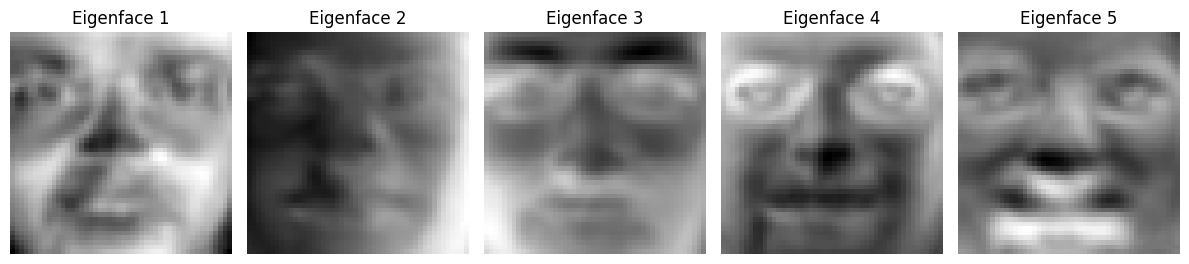

In [30]:
import matplotlib.pyplot as plt

# The original dimensions of your images are 48x48 pixels (2304 features)
img_height, img_width = 48, 48

# Create a figure to plot the first 5 eigenfaces
plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    # Reshape the i-th eigenvector back into the 2D image format
    eigenface = pca_faces.components_[i].reshape(img_height, img_width)
    
    # Plot using a grayscale colormap
    plt.imshow(eigenface, cmap='gray')
    plt.title(f'Eigenface {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

<div dir="rtl">

### توضیح چهره‌های ویژه

**چرا این تصاویر شبیه چهره معمولی نیستند، اما الگوهای مهمی از تغییرات چهره‌ها را نشان می‌دهند؟**

* **دلیل عدم شباهت به چهره معمولی:** این تصاویر (Eigenfaces) نشان‌دهنده یک فرد خاص یا یک تصویر واقعی نیستند؛ بلکه جلوه هندسی و تصویری بردارهای ویژه (Eigenvectors) حاصل از ماتریس کوواریانس داده‌ها هستند. مقادیر پیکسلی آن‌ها نه بر اساس رنگ واقعی پوست، بلکه بر اساس جهت‌های ریاضی بیشترین واریانس (تغییرات آماری) در کل دیتاست تنظیم شده است. به همین دلیل حالتی سایه‌روشن و شبح‌وار دارند.
* **دلیل نمایش الگوهای مهم تغییرات:** با وجود ظاهر انتزاعی، اگر به ۵ چهره ویژه خروجی نگاه کنیم، هر کدام بخش‌های کلیدی و حیاتی ساختار صورت را کدگذاری کرده‌اند. برای مثال، **Eigenface 1** و **Eigenface 3** تفاوت‌ها و تغییرات اصلی در فرم فک، گونه‌ها و کاسه چشم‌ها را نشان می‌دهند. **Eigenface 4** تمرکز شدیدی روی لنز عینک (در نواحی چشم‌ها) و جهت نورپردازی دارد. این الگوها ثابت می‌کنند که PCA توانسته است ویژگی‌های کلیدی صورت انسان (مانند جایگاه چشم، بینی، ابرو و اکسسوری‌هایی مثل عینک) را بدون داشتن هیچ دانش پیشینی و صرفاً از روی توزیع آماری داده‌ها استخراج کند که برای بازسازی و تشخیص هر چهره‌ای در گام‌های بعدی کاملاً کافی است.

</div>

<div dir="rtl">

## ۲.۵ آموزش طبقه‌بند `LDA`

یک طبقه‌بند `LDA` را روی داده‌های تبدیل‌شده با `PCA` آموزش دهید. دقت و ماتریس درهم‌ریختگی را روی داده آزمون گزارش کنید.

</div>

Overall Accuracy of LDA on Test Set: 91.50%


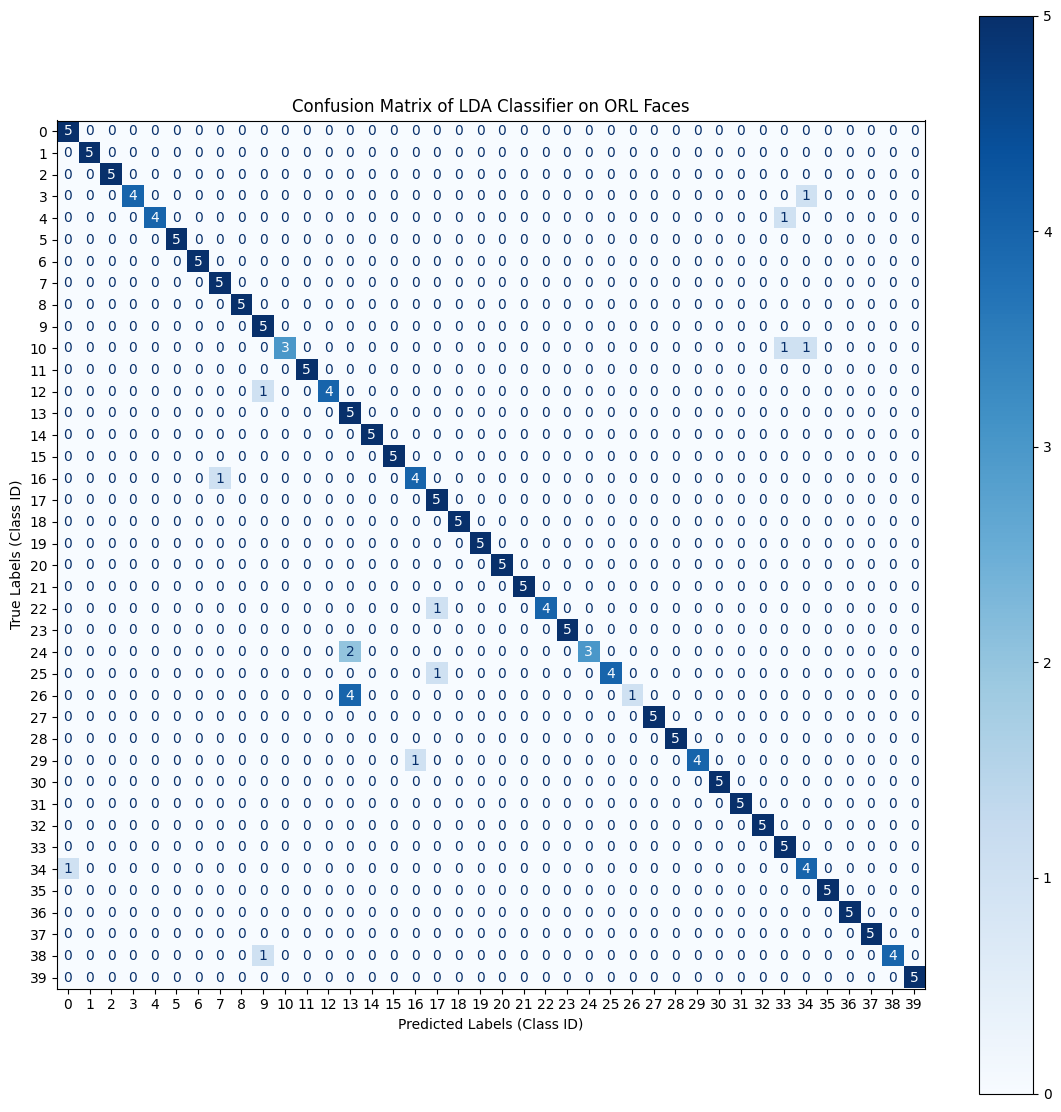

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# Initialize the Linear Discriminant Analysis (LDA) classifier
lda = LDA()

# Train the classifier using the PCA-transformed training data
lda.fit(train_X_pca, train_y)

# Predict the labels for the PCA-transformed test data
pred_y = lda.predict(test_X_pca)

# Calculate and display the overall accuracy score
accuracy = accuracy_score(test_y, pred_y)
print(f"Overall Accuracy of LDA on Test Set: {accuracy * 100:.2f}%")

# Generate the confusion matrix
cm = confusion_matrix(test_y, pred_y)

# Display the confusion matrix graphically
# Since there are 40 classes, we increase the figure size for better readability
fig, ax = plt.subplots(figsize=(14, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues', colorbar=True, values_format='d')

plt.title("Confusion Matrix of LDA Classifier on ORL Faces")
plt.xlabel("Predicted Labels (Class ID)")
plt.ylabel("True Labels (Class ID)")
plt.show()

<div dir="rtl">

### تحلیل طبقه‌بندی

**۱. کدام افراد بیشتر با یکدیگر اشتباه شده‌اند؟**

با بررسی دقیق داده‌های خارج از قطر اصلی در ماتریس درهم‌ریختگی، خطاهای برجسته مدل به شرح زیر است:
* **کلاس ۲۶ با کلاس ۱۳:** بزرگ‌ترین خطای مدل در این بخش رخ داده است؛ جایی که **۴ نمونه** از تصاویر فرد ۲۶ به اشتباه به عنوان فرد ۱۳ پیش‌بینی شده‌اند.
* **کلاس ۲۴ با کلاس ۱۳:** مدل **۲ نمونه** از تصاویر فرد ۲۴ را به عنوان فرد ۱۳ تشخیص داده است.
* **سایر خطاهای تک‌نمونه‌ای (مقدار ۱):** 
  * فرد ۳ با فرد ۳۴ اشتباه شده است.
  * فرد ۴ با فرد ۳۳ اشتباه شده است.
  * فرد ۱۰ با افراد ۳۳ و ۳۴ اشتباه شده است.
  * فرد ۱۲ با فرد ۹ اشتباه شده است.
  * فرد ۱۶ با فرد ۷ اشتباه شده است.
  * فرد ۲۲ با فرد ۱۷ اشتباه شده است.
  * فرد ۲۵ با فرد ۱۷ اشتباه شده است.
  * فرد ۲۹ با فرد ۱۶ اشتباه شده است.
  * فرد ۳۴ با فرد ۰ اشتباه شده است.
  * فرد ۳۸ با فرد ۹ اشتباه شده است.

**۲. دلیل احتمالی آن چیست؟**

* **نقاط کور در ویژگی‌های استخراج‌شده توسط PCA:** مدل PCA بر مبنای جهت‌های بیشترین واریانس عمل می‌کند و به برچسب کلاس‌ها اهمیتی نمی‌دهد (Unsupervised). اگر برخی ویژگی‌های بسیار ظریف و متمایزکننده بین دو فرد (مثلاً فرد ۲۶ و ۱۳) در مؤلفه‌های فرعی حذف‌شده قرار گرفته باشند، مدل در تفکیک نهایی دچار مشکل می‌شود.
* **شباهت ظاهری و پس‌زمینه یکسان:** در دیتاست ORL، تصاویر در پس‌زمینه تیره و شرایط نوری نسبتاً مشابهی ثبت شده‌اند. شباهت‌های ساختاری چهره (مانند فرم مو، داشتن عینک مشابه یا ته ریش) در ترکیب با تغییر موقعیت صورت (چرخش سر و زاویه نگاه) باعث می‌شود بردار ویژگی کاهش‌یافته دو فرد مختلف، در فضای ۵۰ بعدی به شدت به یکدیگر نزدیک شده و مرز تصمیم‌گیری خطی LDA را به اشتباه بیندازد.
* **کمبود داده آموزش برای هر کلاس:** برای هر فرد تنها ۵ تصویر آموزش وجود دارد. اگر تصویر تست یک فرد تغییر حالت شدیدی در چهره (مانند خنده شدید) یا زاویه متفاوتی نسبت به ۵ تصویر آموزش داشته باشد، الگوریتم به سمت شبیه‌ترین فرد بعدی در داده‌های آموزش متمایل می‌شود.

</div>

<div dir="rtl">

## ۲.۶ بررسی اثر تعداد مولفه‌های `PCA`

فرایند استخراج ویژگی با `PCA` و طبقه‌بندی با `LDA` را برای چند مقدار مختلف تعداد مولفه‌ها در بازه ۴۰ تا ۱۰۰ تکرار کنید. دقت آزمون را ذخیره و نمودار دقت بر حسب تعداد مولفه‌ها را رسم کنید.

</div>

In [32]:
pca_dimensions = [40, 50, 60, 70, 80, 90, 100]
accuracies = []

for n_comp in pca_dimensions:
# Initialize PCA with the current number of components
    pca = PCA(n_components=n_comp, whiten=True, random_state=1791)
    
    # Fit on training data and transform both sets
    X_train_pca = pca.fit_transform(train_X)
    X_test_pca = pca.transform(test_X)
    
    # Initialize and train LDA
    lda_model = LDA()
    lda_model.fit(X_train_pca, train_y)
    
    # Predict and calculate accuracy
    y_pred = lda_model.predict(X_test_pca)
    acc = accuracy_score(test_y, y_pred)
    
    # Append accuracy to the list
    accuracies.append(acc)
    print(f"Components: {n_comp} -> Accuracy: {acc * 100:.2f}%")

Components: 40 -> Accuracy: 92.00%
Components: 50 -> Accuracy: 91.50%
Components: 60 -> Accuracy: 91.00%
Components: 70 -> Accuracy: 91.50%
Components: 80 -> Accuracy: 92.00%
Components: 90 -> Accuracy: 92.50%
Components: 100 -> Accuracy: 94.00%


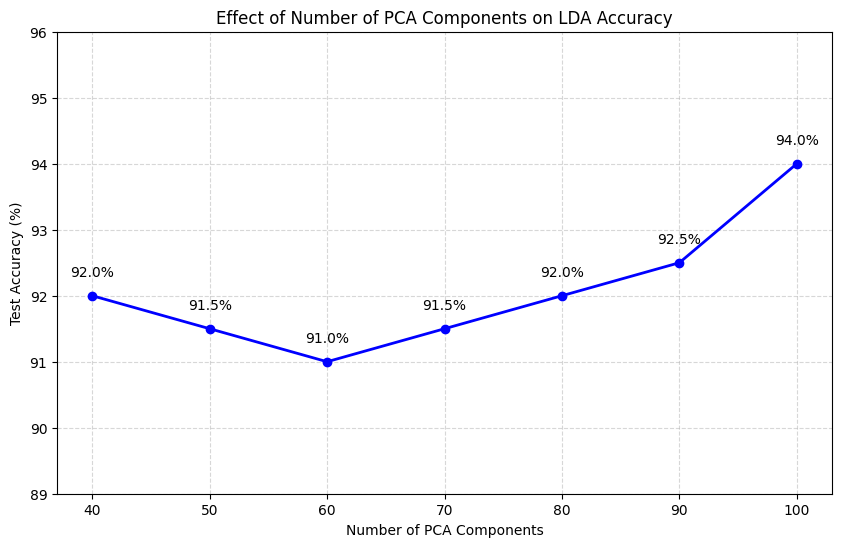

In [33]:
import matplotlib.pyplot as plt

# Plotting the accuracy vs number of PCA components
plt.figure(figsize=(10, 6))
plt.plot(pca_dimensions, [a * 100 for a in accuracies], marker='o', linestyle='-', color='b', linewidth=2)

# Adding values on top of each marker
for i, txt in enumerate(accuracies):
    plt.annotate(f"{txt*100:.1f}%", (pca_dimensions[i], (accuracies[i]*100) + 0.3), ha='center')

plt.title('Effect of Number of PCA Components on LDA Accuracy')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test Accuracy (%)')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.ylim(min(accuracies)*100 - 2, max(accuracies)*100 + 2)
plt.show()

<div dir="rtl">

### جمع‌بندی سؤال دوم

**چه تعداد ویژگی برای این مجموعه‌داده کافی به نظر می‌رسد؟**

**پاسخ:** بر اساس روند نمودار و نتایج عددی استخراج‌شده، **۱۰۰ مؤلفه اصلی (یا بیشتر)** بهترین و کافی‌ترین تعداد ویژگی برای این مجموعه‌داده به نظر می‌رسد. تحلیل دقیق این روند بر اساس خروجی‌ها به شرح زیر است:

1. **افت اولیه عملکرد (بازه ۴۰ تا ۶۰ مؤلفه):** با افزایش مؤلفه‌ها از ۴۰ به ۶۰، دقت مدل از **۹۲.۰۰٪** به کمترین مقدار خود یعنی **۹۱.۰۰٪** نزول می‌کند. دلیل این پدیده آن است که مؤلفه‌های میانی (بازه ۵۰ تا ۶۰) احتمالاً حاوی نویزهای آماری یا تغییرات درون‌کلاسی (مانند زوایای شدید نور و چهره) هستند که مدل Unsupervised پایتون (PCA) آن‌ها را به عنوان اطلاعات واریانس بالا حفظ کرده، اما مخل مرزبندی خطی طبقه‌بند LDA روی داده‌های آزمون شده‌اند.
2. **روند صعودی و جبران عملکرد (بازه ۷۰ تا ۱۰۰ مؤلفه):** از مؤلفه ۷۰ به بعد، شاهد یک جهش و صعود مستمر در دقت مدل هستیم. با رسیدن به ۱۰۰ مؤلفه، دقت سیستم به بیشترین مقدار خود یعنی **۹۴.۰۰٪** می‌رسد. این موضوع نشان می‌دهد ویژگی‌های فرعی‌تر و با واریانس کمتر که در این بازه اضافه شده‌اند، حاوی اطلاعات ساختاری ظریف و بسیار کلیدی برای متمایز کردن چهره‌های شبیه به هم (تفکیک میان‌کلاسی) بوده‌اند.
3. **نتیجه‌گیری نهایی:** از آنجا که تصویر یک موجودیت پیچیده است، محدود کردن ویژگی‌ها به زیر ۶۰ بعد باعث حذف مشخصه‌های متمایزکننده چهره‌ها می‌شود. از طرفی، بالاترین دقت ثبت شده متعلق به **۱۰۰ مؤلفه** است که نشان می‌دهد سیستم برای دست‌یابی به تفکیک‌پذیری بهینه در طبقه‌بندی LDA، به این تعداد ویژگیِ فرعی اما متمایزکننده نیاز مبرم دارد.

</div>

<div dir="rtl">

# چک‌لیست نهایی

قبل از تحویل، مطمئن شوید موارد زیر در نوت‌بوک وجود دارد:

1. اجرای کامل سلول‌ها بدون خطا؛
2. توضیح دلیل انتخاب ویژگی‌ها در سؤال اسپاتیفای؛
3. پیاده‌سازی استانداردسازی از ابتدا؛
4. پیاده‌سازی `K-Means` از ابتدا؛
5. نمودارهای `Silhouette` و `Davies-Bouldin`؛
6. انتخاب و تحلیل مقدار نهایی `k`؛
7. پیاده‌سازی `PCA` از ابتدا برای `IRIS`؛
8. ساخت درست داده آموزش و آزمون برای تصاویر چهره؛
9. نمایش چند چهره ویژه؛
10. آموزش `LDA` و تحلیل دقت؛
11. بررسی اثر تعداد مولفه‌های `PCA`؛
12. توضیح‌های کوتاه بر اساس خروجی واقعی خودتان.

</div>